# Das XOR-Problem

## Warum brauchen neuronale Netze Nichtlinearitäten?

Wir betrachten ein sehr einfaches Klassifikationsproblem.

Die Eingabe besitzt nur zwei Merkmale:

$$
(x_1,x_2)
$$

Die Aufgabe:

- Wenn beide Werte gleich sind → Klasse 0
- Wenn die Werte unterschiedlich sind → Klasse 1

Diese Aufgabe nennt man XOR.

## Daten erzeugen

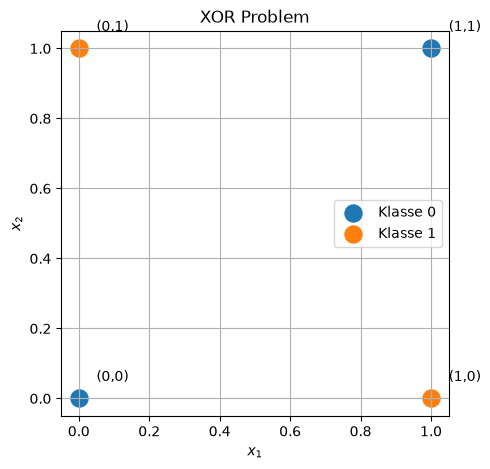

In [1]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y = np.array([
    0,
    1,
    1,
    0
])


plt.figure(figsize=(5,5))

plt.scatter(
    X[y==0,0],
    X[y==0,1],
    s=150,
    label="Klasse 0"
)

plt.scatter(
    X[y==1,0],
    X[y==1,1],
    s=150,
    label="Klasse 1"
)

for i,(x1,x2) in enumerate(X):
    plt.text(
        x1+0.05,
        x2+0.05,
        f"({x1},{x2})"
    )


plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("XOR Problem")
plt.grid()
plt.legend()

plt.show()

In [2]:
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score


model = Perceptron(
    max_iter=1000,
    random_state=42
)


model.fit(X,y)


prediction = model.predict(X)


print(prediction)
print(
    "Accuracy:",
    accuracy_score(y,prediction)
)

[0 0 0 0]
Accuracy: 0.5


### Entscheidungsgrenze visualisieren

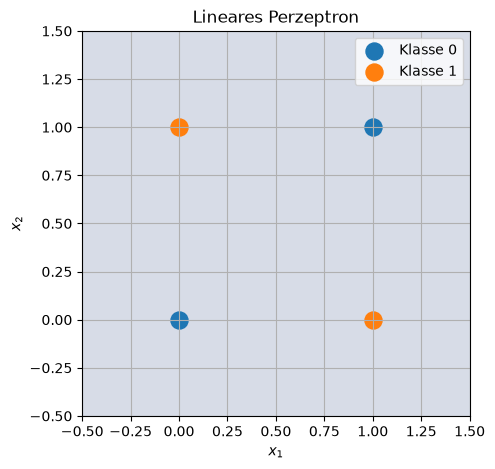

In [3]:
def plot_boundary(model):

    xx, yy = np.meshgrid(
        np.linspace(-0.5,1.5,200),
        np.linspace(-0.5,1.5,200)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]

    pred = model.predict(grid)

    pred = pred.reshape(xx.shape)


    plt.figure(figsize=(5,5))

    plt.contourf(
        xx,
        yy,
        pred,
        alpha=0.2
    )


    plt.scatter(
        X[y==0,0],
        X[y==0,1],
        s=150,
        label="Klasse 0"
    )

    plt.scatter(
        X[y==1,0],
        X[y==1,1],
        s=150,
        label="Klasse 1"
    )


    plt.title("Lineares Perzeptron")
    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$")
    plt.legend()
    plt.grid()

    plt.show()


plot_boundary(model)

### Ein neuronales Netz mit ReLU

In [5]:
# import all needed libraries
# python3.14 does not support tensorfow: use different backend
import os
try:
    from tensorflow import keras
    from tensorflow.keras import layers
except Exception as e:
    print("Cannot import tensorflow: using jax")
    os.environ["KERAS_BACKEND"] = "jax"
    import keras
    from keras import layers


Cannot import tensorflow: using jax


In [10]:
network = keras.Sequential([
    layers.Dense(
        4,
        activation="tanh",
        input_shape=(2,)
    ),

    layers.Dense(
        1,
        activation="sigmoid"
    )
])

network.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.01
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = network.fit(
    X,
    y,
    epochs=2000,
    verbose=0
)

print(network.predict(X))
print(network.evaluate(X, y))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
[[6.1777915e-04]
 [9.9928683e-01]
 [9.9921036e-01]
 [9.0698519e-04]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 1.0000 - loss: 7.5720e-04
[0.0007571967435069382, 1.0]


In [11]:
prediction = network.predict(X)

print(
    np.round(prediction)
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
[[0.]
 [1.]
 [1.]
 [0.]]


### Trainingsverlauf anzeigen

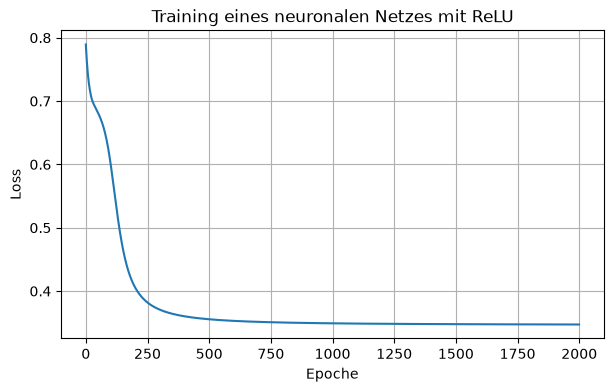

In [8]:
plt.figure(figsize=(7,4))

plt.plot(
    history.history["loss"]
)

plt.xlabel("Epoche")
plt.ylabel("Loss")

plt.title(
    "Training eines neuronalen Netzes mit ReLU"
)

plt.grid()

plt.show()

### Entscheidungsfläche des neuronalen Netzes

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 217us/step


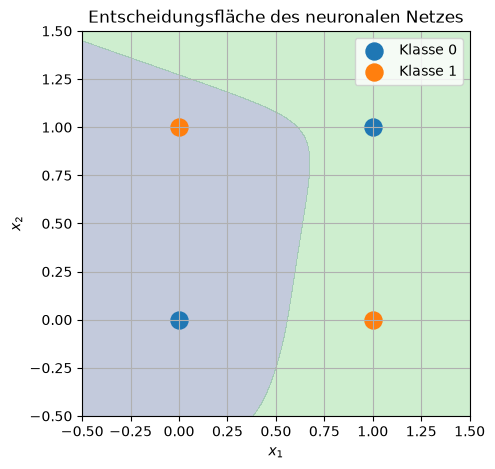

In [9]:
def plot_nn_boundary(network):

    xx, yy = np.meshgrid(
        np.linspace(-0.5,1.5,200),
        np.linspace(-0.5,1.5,200)
    )

    grid=np.c_[xx.ravel(),yy.ravel()]

    pred = network.predict(grid)

    pred = pred.reshape(xx.shape)


    plt.figure(figsize=(5,5))

    plt.contourf(
        xx,
        yy,
        pred,
        levels=[0,0.5,1],
        alpha=0.3
    )


    plt.scatter(
        X[y==0,0],
        X[y==0,1],
        s=150,
        label="Klasse 0"
    )

    plt.scatter(
        X[y==1,0],
        X[y==1,1],
        s=150,
        label="Klasse 1"
    )


    plt.title("Entscheidungsfläche des neuronalen Netzes")

    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$")
    plt.legend()
    plt.grid()

    plt.show()


plot_nn_boundary(network)

change

```
layers.Dense(
    4,
    activation="relu"
)
```

to 
```
layers.Dense(
    4,
    activation=None
)
```

## Erkenntnis

Ein neuronales Netz benötigt Nichtlinearitäten.

Ohne Aktivierungsfunktionen:

$$
Linear + Linear + Linear
=
Linear
$$

Mit Aktivierungsfunktionen:

$$
Linear + Nichtlinear + Linear
=
komplexes Modell
$$

Dadurch können neuronale Netze komplizierte Muster wie Handschriften, Gesichter oder Sprache erkennen.